In [138]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

In [139]:
embs = {
    "金毛": [0.2, 0.4, 0.8, -0.1],
    "西瓜": [-3.7, -4.2, 1.1, 2.1],
    "丁师兄": [-2.4, 0.1, -0.3, 4.5]
}

q = torch.FloatTensor([list(embs.values())])
print("q: ", q, q.shape)

k = torch.FloatTensor([list(embs.values())])
print("k: ", k, k.shape)

v = torch.FloatTensor([list(embs.values())])
print("v: ", v, v.shape)

q:  tensor([[[ 0.2000,  0.4000,  0.8000, -0.1000],
         [-3.7000, -4.2000,  1.1000,  2.1000],
         [-2.4000,  0.1000, -0.3000,  4.5000]]]) torch.Size([1, 3, 4])
k:  tensor([[[ 0.2000,  0.4000,  0.8000, -0.1000],
         [-3.7000, -4.2000,  1.1000,  2.1000],
         [-2.4000,  0.1000, -0.3000,  4.5000]]]) torch.Size([1, 3, 4])
v:  tensor([[[ 0.2000,  0.4000,  0.8000, -0.1000],
         [-3.7000, -4.2000,  1.1000,  2.1000],
         [-2.4000,  0.1000, -0.3000,  4.5000]]]) torch.Size([1, 3, 4])


In [140]:
from dataclasses import dataclass

@dataclass
class ModelArgs:
    n_heads: int
    dim: int # 维度
    max_seq_len: int
    dropout: float

args = ModelArgs(8, 512, 1024, 0.1)
print(args)


ModelArgs(n_heads=8, dim=512, max_seq_len=1024, dropout=0.1)


In [141]:
class MultiHeadAttention(nn.Module):
    #is_causal 是否是masked causal attention
    def __init__(self, args: ModelArgs, is_casual: bool = False): 
        self.args = args
        super().__init__()

        assert args.dim % args.n_heads == 0

        self.head_dim = args.dim  // args.n_heads
        self.n_heads = args.n_heads 
        self.is_casual = is_casual

        self.wq = nn.Linear(args.dim, args.dim, bias=False)
        self.wk = nn.Linear(args.dim, args.dim, bias=False)
        self.wv = nn.Linear(args.dim, args.dim, bias=False)

        self.wo = nn.Linear(args.dim, args.dim, bias=False)

        self.attn_dropout = nn.Dropout(args.dropout)

        self.res_dropout = nn.Dropout(args.dropout)

        if self.is_casual:
            # [batch_size, n_heads, seq_len, seq_len]
            # 生成一个三角形矩阵，上三角为inf，下三角为0
            # 用于掩码未来位置的注意力
            mask = torch.full((1,1, args.max_seq_len, args.max_seq_len), float('-inf'))
            mask = mask.triu(diagonal=1)

            # 注册缓冲区，用于存储掩码
            # 缓冲区的形状为 [1, 1, seq_len, seq_len]
            # 用于在前向传播中应用掩码
            # 缓冲区的元素为inf或0
            # 会被模型存下来
            self.register_buffer('mask', mask)
        

    def forward(self, q, k, v):
        # [batch_size, seq_len, dim]
        batch_size, seq_len, dim = q.shape
            # 计算Q, K, V，维度为：[batch_size, seq_len, dim] * [dim, dim] -> [batch_size, seq_len, dim]
        Q, K, V = self.wq(q), self.wk(k), self.wv(v)

        # 将Q, K, V拆分成多头，[batch_size, seq_len, n_heads, head_dim]
        Q = Q.view(batch_size, seq_len, self.n_heads, self.head_dim)
        K = K.view(batch_size, seq_len, self.n_heads, self.head_dim)
        V = V.view(batch_size, seq_len, self.n_heads, self.head_dim)

        # n 个 [batch_size, seq_len, head_dim] 矩阵，然后按照batch_size的维度进行合并 [batch_size, n_heads, seq_len, head_dim]
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        score = torch.matmul(Q, K.transpose(-2, -1)) / self.head_dim**0.5

        # 计算掩码
        if self.is_casual:
            score = score + self.mask[:, :, :seq_len, :seq_len]

        # 计算注意力权重
        score = torch.softmax(score, dim=-1).type_as(Q)

        # V
        output = torch.matmul(score, V)

        # 合并多头,逆向转换维度为 [batch_size, seq_len, dim]
        output = output.transpose(1, 2)
        #将张量的内存布局转换为 [batch_size, seq_len, n_heads, head_dim] -> [batch_size, seq_len_len, dim]
        output = output.contiguous().view(batch_size, seq_len, dim)

        # 输出
        output = self.wo(output)
        output = self.res_dropout(output)
        return output, score



Case 1

In [142]:
args = ModelArgs(n_heads=2, dim=4, dropout=0.1, max_seq_len=10)
print(args)

# MHA
mha = MultiHeadAttention(args, is_casual=False)
output, att_score = mha(q, k, v)
print("output: ", output)
print("att_score: ", att_score)

ModelArgs(n_heads=2, dim=4, max_seq_len=10, dropout=0.1)
output:  tensor([[[-0.6391,  1.2944, -1.2356, -0.5397],
         [-0.6220,  2.5517, -2.4456, -0.8831],
         [-0.4354,  2.1190, -1.8913, -0.6756]]], grad_fn=<MulBackward0>)
att_score:  tensor([[[[0.2876, 0.3620, 0.3505],
          [0.0361, 0.8851, 0.0788],
          [0.1298, 0.7174, 0.1528]],

         [[0.3725, 0.3600, 0.2675],
          [0.1407, 0.1288, 0.7305],
          [0.5075, 0.2476, 0.2449]]]], grad_fn=<SoftmaxBackward0>)


In [143]:
! pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://bytedpypi.byted.org/simple/


[[0.3724963  0.35996464 0.26753902]
 [0.14073874 0.12880798 0.73045325]
 [0.50751483 0.24757543 0.24490978]]


<Axes: >

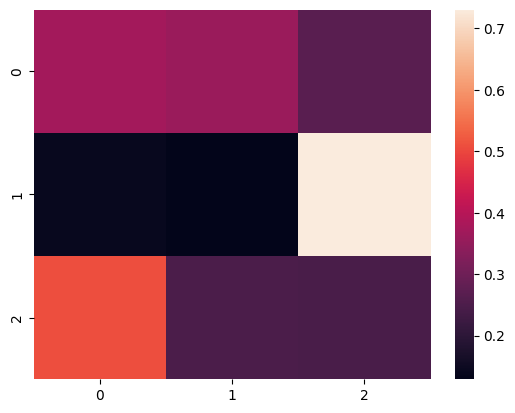

In [144]:
import seaborn as sns

# 热力图
print(att_score[0, 1].detach().numpy())

sns.heatmap(att_score[0, 1].detach().numpy())

In [145]:
args = ModelArgs(n_heads=2, dim=4, dropout=0.1, max_seq_len=10)
print(args)

# MHA
mha = MultiHeadAttention(args, is_casual=True)
output, att_score = mha(q, k, v)
print("output: ", output)
print("att_score: ", att_score)

ModelArgs(n_heads=2, dim=4, max_seq_len=10, dropout=0.1)
output:  tensor([[[-0.0893, -0.0766,  0.1000,  0.0051],
         [ 0.4976, -0.2180,  0.0598,  0.0000],
         [ 0.2635,  0.8597, -1.0377,  0.0000]]], grad_fn=<MulBackward0>)
att_score:  tensor([[[[1.0000, 0.0000, 0.0000],
          [0.4166, 0.5834, 0.0000],
          [0.2357, 0.5096, 0.2547]],

         [[1.0000, 0.0000, 0.0000],
          [0.2651, 0.7349, 0.0000],
          [0.0333, 0.0567, 0.9099]]]], grad_fn=<SoftmaxBackward0>)


[[1.         0.         0.        ]
 [0.26508582 0.73491424 0.        ]
 [0.03333885 0.05673598 0.90992516]]


<Axes: >

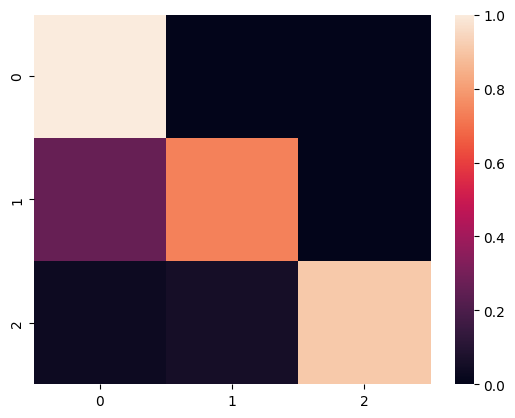

In [146]:
# 热力图
print(att_score[0, 1].detach().numpy())

sns.heatmap(att_score[0, 1].detach().numpy())

In [147]:
args = ModelArgs(n_heads=8, dim=1024, dropout=0.1, max_seq_len=512)
print(args)

batch_size = 10
seq_len = 128

x = torch.randn(batch_size, seq_len, args.dim)

# MHA
mha = MultiHeadAttention(args, is_casual=False)
output, att_score = mha(x, x, x)
print("output shape: ", output.shape)
print("att_score shape: ", att_score.shape)

ModelArgs(n_heads=8, dim=1024, max_seq_len=512, dropout=0.1)
output shape:  torch.Size([10, 128, 1024])
att_score shape:  torch.Size([10, 8, 128, 128])


[[0.0076286  0.0102217  0.00715729 ... 0.00569242 0.0074087  0.00608496]
 [0.00653452 0.01086485 0.0051321  ... 0.00757473 0.00668648 0.00588167]
 [0.00611154 0.0073311  0.00686314 ... 0.0046271  0.00699281 0.00459855]
 ...
 [0.01099239 0.01255004 0.0048318  ... 0.01187056 0.00523561 0.00645958]
 [0.00570666 0.00525125 0.00708119 ... 0.0082553  0.00979026 0.00581527]
 [0.00906576 0.00543014 0.00975321 ... 0.00537842 0.00775683 0.00798026]]


<Axes: >

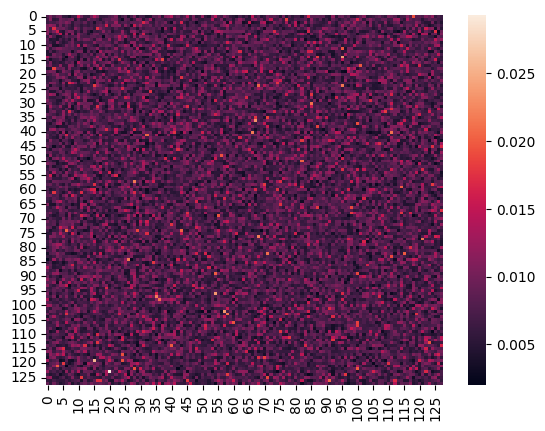

In [148]:
# 热力图
print(att_score[0, 0].detach().numpy())
sns.heatmap(att_score[0, 0].detach().numpy())